In [2]:
import os
import itertools
import random
from collections import defaultdict

import numpy as np
from tqdm import tqdm

from rule import *

from datasets import Dataset, concatenate_datasets, disable_progress_bars

from plotnine import *
import pandas as pd

c:\alien_filter\alien_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
## simple agent setup

######### 1 sample from rules
# vars - memory - nr_samples
# how they are sampled? 
# A, random
# B, similar (foraging)
# C, meta
#   C1, by nr_features
#   C2, by logic (read up on logic complexity computationally)
#   C3, by mix?
# D, by mix of the above?

######### 2 encounter stimuli 

# A, test based on one of the rules
#   How rule is selected? 
#    A, Probabilistic? softmax function?
#    B, hypothesis testing? one of the rules is selected to test multiple times despite its prob?
#    C,  mix of these?

# B, update weights, how ???
#    A, uniform? everything that was in accordance changes by x amount
#    A1, what is x?? 1? 0.1
#    B, 
# B2, update weights, when ???
#    A, without choice? 
#      test all rules "simultaneously"
#    B, test one exact rule, and let its result affect the rest?
#       B1, by proximity? (graph like rule connections, closer rules affected more?)
#       B2, by some memory degradation? (rules are ordered in memory sequence, ones further in line are less affected?)

# 3 resample
# When?
#   A, instantly when a rule approaches 0
#   B, at given intervals
#   C, at random itervals
#   D, based on some hypothesis testing? in connection with previous points, e.g when rule 1 is falsified, resample all?
# How?
#   A, remove from sampling pool,
#   B, Keep in sampling pool,
#   C, keep in sampling pool but lessen chance of resampling
# What's the limit?
#   A, set limit, less than e.g 0.1
#   B, dynamix limit
#       B1, based on n_max, e.g (1/n_max)/2?
#       B2, based on the p of the other rules?
#       B3, based on changing, if unchanged for x turns etc.
# HOW TO RESAMPLE??? (similar to original choice)
#   A, by meta???
#   B, KEEP previous choices in memory? Why would you select a new rule with blue, if ble was out one turn ago
#   B1, how much memory to keep 5+-2?
#   B2, remove rules based on important features? e.g if Blue out, don't select blue and x again
#   B3, remove by rule proximity?

# 4 choose rule
# ok, we have the  probs, but how to determine the rule?
# A, make choices always based on the top rule first, and then infer the rest, based on the result, (add memory attention etc)
# B, keep simultaneous eval, set threshold like 0.6
# C, dual-phase exploration/exploitation?

In [11]:
def random_sampler_remove(all_rules_ds:Dataset,
                   nr_samples:int):
    s1 = random.sample(range(len(all_rules_ds)),nr_samples)
    new_ds = Dataset.from_dict(all_rules_ds[s1])
    all_rules_ds = all_rules_ds.filter(lambda ds:ds["rule"] not in new_ds["rule"])
    
    
    return new_ds, all_rules_ds

def compare_stimuli_all(rule_ds:Dataset,
                        stimuli:list[int],
                        real_rule:Rule,
                        learning_rate:float=0.1):

    #check if stimuli passes for all rules
    if stimuli in rule_ds["passes"]:
        passed_stim = True
    else:
        passed_stim = False
    rule_ds.update({"passed_stim":passed_stim})
    #check result
    res = real_rule.check_stimuli(stimuli)
    if res == rule_ds["passed_stim"]:
        correct = learning_rate
    else:
        correct = 0

    #if already exist, update:
    try:
        if rule_ds["correct"] == None:
            rule_ds.update({"correct":0})
        correct = correct + rule_ds["correct"]
    except KeyError:
        pass

  
    rule_ds.update({"correct":correct})
    return rule_ds
    
def init_p_vals(rule_ds):
    try:
        p_val = rule_ds["p_val"] + 1
    except (KeyError,TypeError):
        p_val = 1

    rule_ds.update({"p_val":p_val})

    return rule_ds

def proportional_re_weigh(rule_ds,weights:list[float]):
    #add up
    w_sums = sum(weights)

    new_weight = rule_ds["p_val"] / w_sums
    rule_ds.update({"p_c":new_weight})
    return rule_ds

def compare_stimuli(rule_ds:Dataset,
                        stimuli:list[int]):
    #check if stimuli passes for all rules
    if stimuli in rule_ds["passes"]:
        passed_stim = True
    else:
        passed_stim = False
    rule_ds.update({"passed_stim":passed_stim})
    return rule_ds

def instant_resample_filter(rule_ds:Dataset, 
                            correct_c: bool,
                      removed_rules:list[str]):
    """
    removes rules if they did not pass criteria,
    fills up with new rules until n_max reached
    """

    if rule_ds["passed_stim"] != correct_c:

        removed_rules.append(rule_ds["rule"])
        
        return False
    else:
        return True

In [6]:
rule_ds = Dataset.from_json("rule_lookup.json")
rule_ds = Dataset.from_list([{"rule":i,"passes":j} for i, j in zip(rule_ds[0].keys(), rule_ds[0].values())])

disable_progress_bars()

In [12]:
#random rule
tst_rule = Rule()
tst_rule.randomize_rule()

memory = 5
#sample from all rules
r1, all_rules = random_sampler_remove(rule_ds, memory)
#initiate probs
r1 = r1.map(init_p_vals)
r1 = r1.map(proportional_re_weigh,
            fn_kwargs={"weights":r1["p_val"]})

#tst_rule = Rule(r1[0]["rule"])
#tst_rule.formalize_rule()
removed_rules = []
game_list = []
guess_list = []
c_count = 0
correct_check = 8


for stim in range(100):
    #random stim
    random_stim = stimuli_maker()
    ##############use rule
    r1 = r1.map(compare_stimuli,
                fn_kwargs={"stimuli":random_stim})
    #select rule
    max_p_c = r1["p_c"].index(max(r1["p_c"]))
    c_guess = r1[max_p_c]["passed_stim"]
    #drop incorrects
    c_choice = tst_rule.check_stimuli(random_stim)
    r1 = r1.filter(instant_resample_filter,
                   fn_kwargs={"removed_rules":removed_rules,
                              "correct_c":c_choice})
    
    #refill memory
    if len(r1) < memory:
        r2, all_rules = random_sampler_remove(
                            all_rules,
                            memory-len(r1))
        r1 = concatenate_datasets([r1,r2])
    else:
        pass
    
    #initalize new rule values
    r1 = r1.map(init_p_vals)
    #proportional o weighing
    r1 = r1.map(proportional_re_weigh,
            fn_kwargs={"weights":r1["p_val"]})
    print(r1["p_c"][:])
    
    #save progress for plotting
    for i in r1:
        game = {"rule":i.get("rule"),
                    "turn":stim,
                    "p":i.get("p_c")} 
        game_list.append(game)

    guess = {"guess":c_guess,"answer":c_choice,"turn":stim}
    guess_list.append(guess)
    
    ######break when 8 correct
    
    if c_choice == c_guess:
        c_count +=1
    else:
        c_count = 0
    
    if c_count == correct_check:
        print(f"8 correct reached at round {stim}:\n max p:{r1[max_p_c]["p_c"]}\nRule: {r1[max_p_c]["rule"]}\nReal rule: {tst_rule.v_rule}")
        break


    

[0.25, 0.25, 0.25, 0.125, 0.125]
[0.375, 0.25, 0.125, 0.125, 0.125]
[0.2857142857142857, 0.2857142857142857, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285]
[0.375, 0.25, 0.125, 0.125, 0.125]
[0.4, 0.2, 0.2, 0.1, 0.1]
[0.3333333333333333, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666]
[0.2857142857142857, 0.2857142857142857, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285]
[0.375, 0.25, 0.125, 0.125, 0.125]
[0.375, 0.25, 0.125, 0.125, 0.125]
[0.3333333333333333, 0.2222222222222222, 0.2222222222222222, 0.1111111111111111, 0.1111111111111111]
[0.3333333333333333, 0.2222222222222222, 0.2222222222222222, 0.1111111111111111, 0.1111111111111111]
[0.36363636363636365, 0.2727272727272727, 0.18181818181818182, 0.09090909090909091, 0.09090909090909091]
[0.38461538461538464, 0.23076923076923078, 0.15384615384615385, 0.15384615384615385, 0.07692307692307693]
[0.6, 0.1, 0.1, 0.1, 0.1]
[0.5833333333333334, 0.16666666666666666, 0.08333

In [1]:
import os
import itertools
import random
from collections import defaultdict

import numpy as np
from tqdm import tqdm

from rule import *

from datasets import Dataset, concatenate_datasets, disable_progress_bars

from plotnine import *
import pandas as pd

from player import Player_Base
from game import alien_game


rule_ds = Dataset.from_parquet("rules.parquet")
disable_progress_bars()
p1 = Player_Base(all_rules_ds=rule_ds)
rule = Rule()
rule.randomize_rule()
g1 = alien_game(rule=rule,
                player=p1)

c:\alien_filter\alien_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
p1 = Player_Base(all_rules_ds=rule_ds)
rule = Rule()
rule.randomize_rule()
g1 = alien_game(rule=rule,
                player=p1)
g1.play()

  0%|          | 0/100 [00:00<?, ?it/s]

turn 0 : CGC : 1


  1%|          | 1/100 [00:03<06:31,  3.95s/it]

turn 1 : CGC : 0


  2%|▏         | 2/100 [00:05<04:15,  2.60s/it]

...

turn 35 : CGC : 6


 36%|███▌      | 36/100 [00:50<01:10,  1.10s/it]

turn 36 : CGC : 7


 37%|███▋      | 37/100 [00:51<01:27,  1.40s/it]

turn 37 : CGC : 8


'Arms_Up and ( No_Spots or Eyes_With_Stalk and Blue )'

In [6]:
g1.game_overview.get("meta_data")

{'status': 'win',
 'n_turns': 37,
 'correct_rule': 'Arms_Up and ( No_Spots or Eyes_With_Stalk and Blue )',
 'max_p_rule': 'Thick_Legs and Arms_Up and ( Eyes_Without_Stalk or Green )',
 'max_p': 0.4}

In [7]:
g1.correct_guess_counter

8

c:\alien_filter\alien_venv\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_text : Removed 10 rows containing missing values.


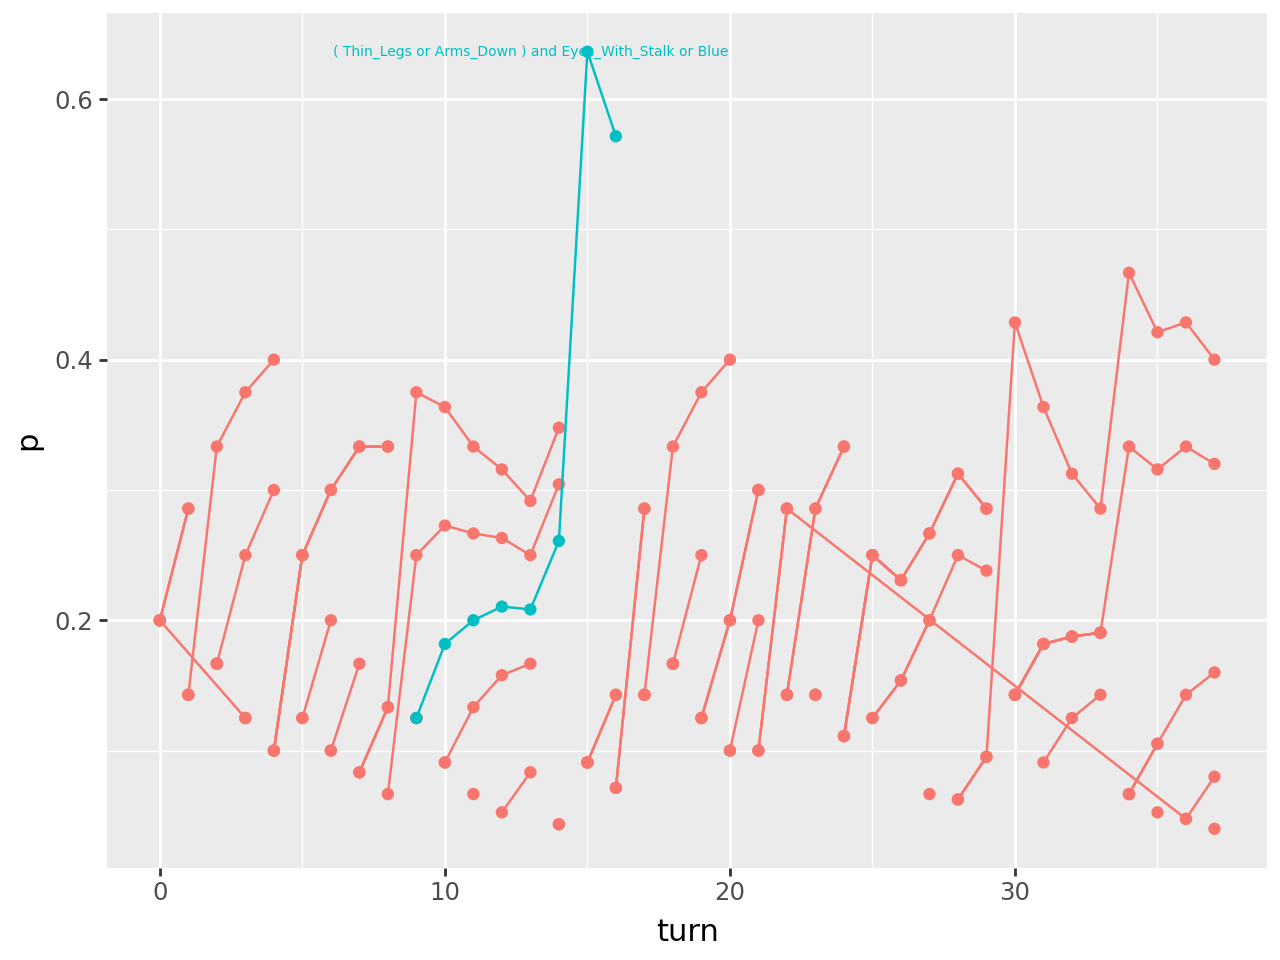

In [8]:
g1.plot_game()

c:\alien_filter\alien_venv\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_text : Removed 10 rows containing missing values.


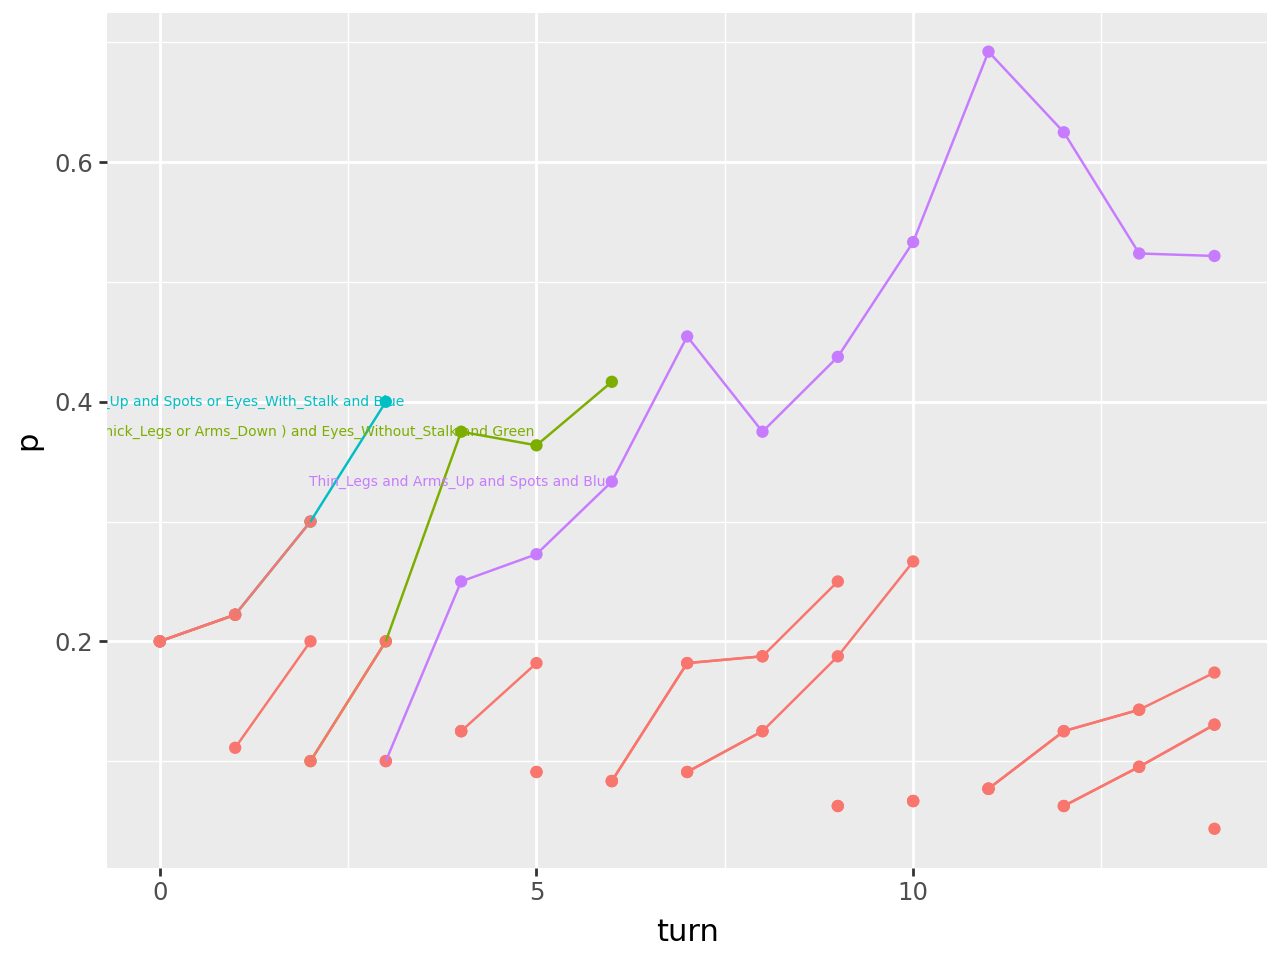

In [ ]:
###plotting
#set boundary for displaying rule
disp_bound = 0.3
[i.update({"rule_disp":i.get("rule")}) if i.get("p") > disp_bound else i.update({"rule_disp":" "}) for i in game_list]
#copy row for color matching
[i.update({"rule_disp_c":i.get("rule_disp")}) for i in game_list]
#remove mulyiple rule_disps for the same rule
rule_disp_o = defaultdict(int)
for i in game_list:
    rule_disp_o[i.get("rule_disp")] += 1

[i.update({"rule_disp":" "}) for idx_i, i in enumerate(game_list) if i.get("rule_disp") in rule_disp_o.keys() and i.get("rule_disp") in [d.get("rule_disp") for d in game_list[:(idx_i-1)]]]

#read rule to rule_disp_c if at some point the rule went below threshold
rules_above_treshold = list(set([i.get("rule") for i in game_list if i.get("p") > disp_bound]))
[i.update({"rule_disp_c":i.get("rule")}) for i in game_list if i.get("rule") in rules_above_treshold]

plot_it = pd.DataFrame(game_list)

(
    ggplot(plot_it, aes("turn","p",group= "rule", color= "rule_disp_c"))
    + geom_point()
    + geom_line()
    + geom_text(aes(label = "rule_disp"), size = 5, nudge_x = -2)
    + xlim(0,max(plot_it["turn"])) 
    + theme(legend_position="none")
)

c:\alien_filter\alien_venv\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_text : Removed 10 rows containing missing values.


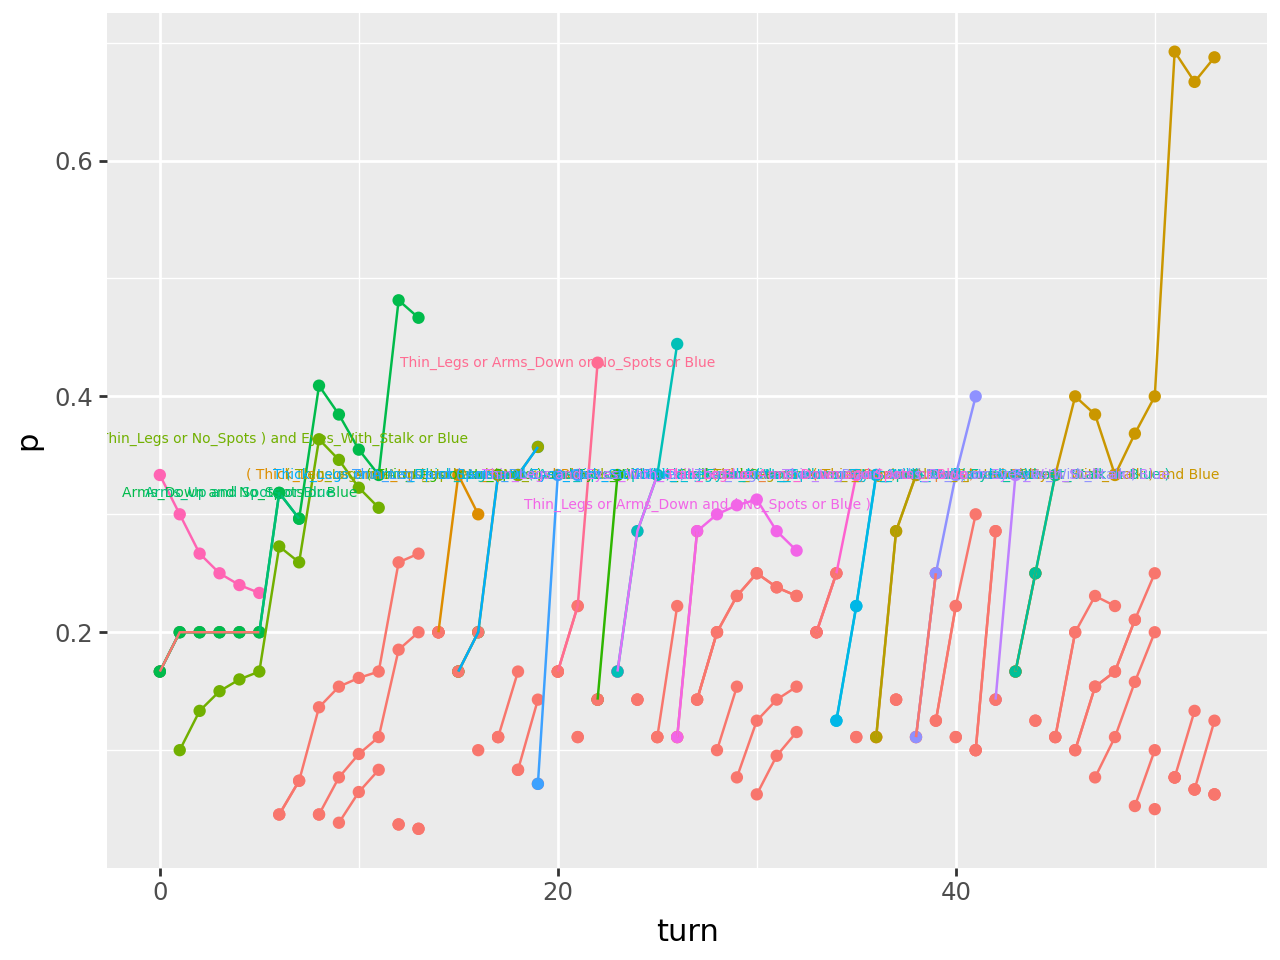

In [9]:
###plotting
#set boundary for displaying rule
disp_bound = 0.3
[i.update({"rule_disp":i.get("rule")}) if i.get("p") > disp_bound else i.update({"rule_disp":" "}) for i in game_list]
#copy row for color matching
[i.update({"rule_disp_c":i.get("rule_disp")}) for i in game_list]
#remove mulyiple rule_disps for the same rule
rule_disp_o = defaultdict(int)
for i in game_list:
    rule_disp_o[i.get("rule_disp")] += 1

[i.update({"rule_disp":" "}) for idx_i, i in enumerate(game_list) if i.get("rule_disp") in rule_disp_o.keys() and i.get("rule_disp") in [d.get("rule_disp") for d in game_list[:(idx_i-1)]]]

#read rule to rule_disp_c if at some point the rule went below threshold
rules_above_treshold = list(set([i.get("rule") for i in game_list if i.get("p") > disp_bound]))
[i.update({"rule_disp_c":i.get("rule")}) for i in game_list if i.get("rule") in rules_above_treshold]

plot_it = pd.DataFrame(game_list)

#remove small ps for plotting

(
    ggplot(plot_it, aes("turn","p",group= "rule", color= "rule_disp_c"))
    + geom_point()
    + geom_line()
    + geom_text(aes(label = "rule_disp"), size = 5, nudge_x = -2)
    + xlim(0,max(plot_it["turn"])) 
    + theme(legend_position="none")
)